In [1]:
from collections import defaultdict
import astropy.table as at
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro.distributions as dist
from numpyro_ext import distributions as distx

%matplotlib inline
jax.config.update("jax_enable_x64", True)

## Setup

We observe radial velocity data $v$ for a set of $N$ sources at distinct observation times $t$. Let's assume that the sources observed are the luminous star in a bunch of binary systems where the companions are nonluminous (i.e., SB1 systems). For simplicity, we enforce that the orbits are circular, the eccentricities are zero, the systemic velocities are zero, and the angles are all zero. For this simplified model, the radial velocity data for a given source is generated by the model: 
$$
v(t) = K \, \cos(2\pi t / P)
$$
where $K$ is the semi-amplitude and $P$ is the period of the orbit. The data are also noisy, with varied quality, but all Gaussian noise. Let's simulate some data.

First, we generate the "true" parameters for each star:

In [2]:
n_stars = 1024

rng = np.random.default_rng(seed=12345)

# number of observations per star
n_times = np.exp(rng.uniform(np.log(3), np.log(100), size=n_stars)).astype(int)
time_baseline = 100.0

# period values per star
max_period = 500.0
true_periods = np.exp(rng.uniform(np.log(1.0), np.log(max_period), n_stars))

# amplitudes
true_amps = rng.choice([-1, 1], size=n_stars) * np.exp(
    rng.uniform(-1, 1.0, size=n_stars)
)

We now have to define what we mean by "binary fraction" to get the true binary fraction of the sample. This amounts to some selection in the physical parameters. In the case of real systems, this might be a selection on periods (to get "close-binaries") and a selection on companion mass (i.e. to distinguish stellar-mass companions vs. others). Here, we will just define a selection on the period and semi-amplitude:

In [3]:
binary_max_period = time_baseline
binary_min_amp = 1.0
true_binary_frac = (
    np.sum((true_periods < binary_max_period) & (np.abs(true_amps) > binary_min_amp))
    / n_stars
)
print(f"True binary fraction: {true_binary_frac:.3f}")

True binary fraction: 0.341


Now we can generate the radial velocity data for each star, including noise:

In [4]:
rv_data = defaultdict(list)
for i in range(n_stars):
    # Generate random times for each star
    rv_data["time"].append(np.sort(rng.uniform(0, time_baseline, size=n_times[i])))

    # Generate random radial velocities for each star
    rv_data["rv_err"].append(np.exp(rng.uniform(-1, 1.0, size=n_times[i])))
    rv_data["rv"].append(
        true_amps[i] * np.cos(2 * np.pi * rv_data["time"][i] / true_periods[i])
        + rng.normal(scale=rv_data["rv_err"][i], size=n_times[i])
    )

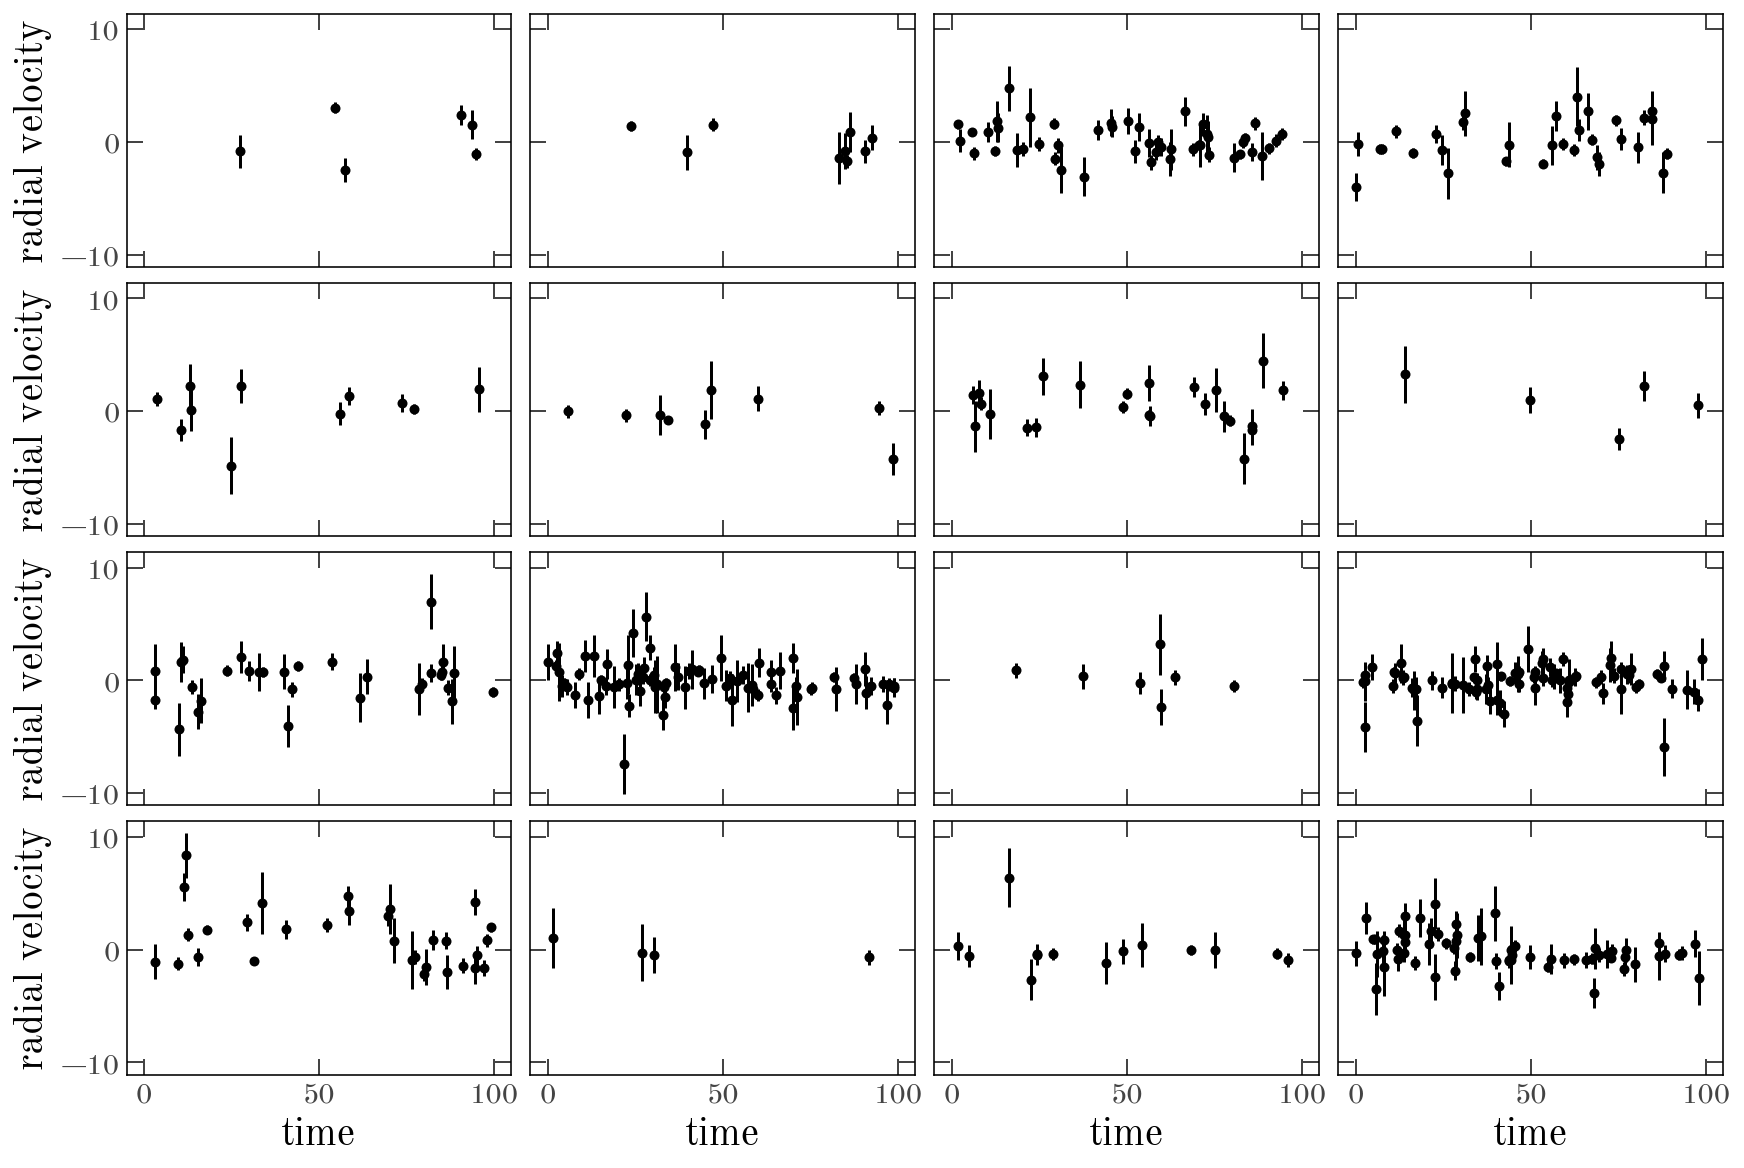

In [5]:
fig, axes = plt.subplots(
    4, 4, figsize=(12, 8), sharex=True, sharey=True, layout="constrained"
)

for i, ax in enumerate(axes.flatten()):
    ax.errorbar(
        rv_data["time"][i], rv_data["rv"][i], yerr=rv_data["rv_err"][i], fmt="o"
    )

for ax in axes[:, 0]:
    ax.set_ylabel("radial velocity")
for ax in axes[-1, :]:
    ax.set_xlabel("time")

## The Joker-style rejection sampler

We'll implement a rejection sampler that:
1. Samples periods from a prior
2. Analytically marginalizes over the amplitude (linear parameter)
3. Uses rejection sampling based on the marginalized likelihood
4. Samples amplitudes from their conditional distribution for accepted samples

The key trick: for a linear parameter $K$, the likelihood is Gaussian in $K$, so we can analytically compute the marginal likelihood and then sample $K$ from its posterior distribution.

In [6]:
# Pad all data to the same length (max number of observations)
# This is a hack so that JIT doesn't recompile for each star of different n_obs...
max_n_obs = np.max(n_times)
print(f"Max observations: {max_n_obs}")


def pad_to_length(arr, length, pad_value):
    """Pad array to specified length."""
    padded = np.full(length, pad_value)
    padded[: len(arr)] = arr
    return padded


# Create padded arrays for all stars
t_padded = jnp.array([pad_to_length(t, max_n_obs, 0.0) for t in rv_data["time"]])
rv_padded = jnp.array([pad_to_length(rv, max_n_obs, 0.0) for rv in rv_data["rv"]])
rv_err_padded = jnp.array(
    [pad_to_length(err, max_n_obs, jnp.inf) for err in rv_data["rv_err"]]
)

print(
    f"Padded shapes: t={t_padded.shape}, rv={rv_padded.shape}, rv_err={rv_err_padded.shape}"
)

Max observations: 99
Padded shapes: t=(1024, 99), rv=(1024, 99), rv_err=(1024, 99)


In [7]:
linear_prior_scale = 100.0


@jax.jit
def compute_all_log_likelihoods(periods, t_all, rv_all, rv_err_all):
    """Compute log likelihoods for all periods and all stars using scan.

    Parameters
    ----------
    periods : array (n_periods,)
    t_all : array (n_stars, max_n_obs)
    rv_all : array (n_stars, max_n_obs)
    rv_err_all : array (n_stars, max_n_obs)

    Returns
    -------
    lnL : array (n_stars, n_periods)
    """

    def compute_star_likelihoods(t, rv, rv_err):
        """Compute likelihoods for one star, all periods."""
        # Create mask for valid (non-padded) points
        # Padded points have rv_err = inf
        valid_mask = jnp.isfinite(rv_err)

        # Replace padded points with valid values (won't affect likelihood)
        # Set padded values to 0 error so they contribute nothing
        rv_err_safe = jnp.where(valid_mask, rv_err, 1e10)

        def single_period_likelihood(period):
            design_matrix = jnp.cos(2 * jnp.pi * t / period)[:, None]
            linear_prior = dist.Normal(0.0, 1000.0)
            marginalized = distx.MarginalizedLinear(
                design_matrix,
                linear_prior,
                dist.Normal(jnp.zeros(len(rv)), rv_err_safe),
            )
            return marginalized.log_prob(rv)

        return jax.vmap(single_period_likelihood)(periods)

    # use scan to loop over stars without vmapping (because memory)
    def scan_fn(carry, x):
        t, rv, rv_err = x
        lnL = compute_star_likelihoods(t, rv, rv_err)
        return carry, lnL

    _, lnL_all = jax.lax.scan(scan_fn, None, (t_all, rv_all, rv_err_all))

    return lnL_all

In [8]:
@jax.jit
def rejection_step(key, lnL_all):
    """Perform rejection sampling for all stars

    Parameters
    ----------
    key : PRNGKey
    lnL_all : array (n_stars, n_periods)

    Returns
    -------
    weights : array (n_stars, n_periods)
    accepted : array (n_stars, n_periods) boolean
    """
    # Normalize weights per star
    lnL_max = jnp.max(lnL_all, axis=1, keepdims=True)
    weights = jnp.exp(lnL_all - lnL_max)

    # Rejection sampling
    uniform_draws = jax.random.uniform(key, shape=lnL_all.shape)
    accepted = uniform_draws < weights

    return weights, accepted

In [9]:
@jax.jit
def sample_K_given_period(key, periods, t, rv, rv_err):
    """Sample amplitude K given period from the conditional posterior."""

    def sample_single_K(period, subkey):
        # Design matrix for this period
        design_matrix = jnp.cos(2 * jnp.pi * t / period)[:, None]

        # Linear prior on K
        linear_prior = dist.Normal(0.0, 1000.0)

        # Create the marginalized distribution
        marginalized = distx.MarginalizedLinear(
            design_matrix,
            linear_prior,
            dist.Normal(jnp.zeros(len(rv)), rv_err),
        )

        # Sample K from the conditional posterior
        K_sample = marginalized.conditional(rv).sample(subkey)

        return K_sample[0]  # Return scalar (remove the [0] dimension)

    # Generate keys for each period
    keys = jax.random.split(key, len(periods))

    # Sample K for each period
    K_samples = jax.vmap(sample_single_K)(periods, keys)

    return K_samples

In [10]:
def run_batched_rejection_sampler(
    key,
    t_padded,
    rv_padded,
    rv_err_padded,
    n_prior_samples=100_000,
    n_posterior_samples=256,
    period_min=1.0,
    period_max=500.0,
):
    """
    Run rejection sampler on all stars in a single batched computation.
    """
    key1, key2, key3 = jax.random.split(key, 3)

    # Generate shared period samples
    lnP_samples = jax.random.uniform(
        key1,
        shape=(n_prior_samples,),
        minval=jnp.log(period_min),
        maxval=jnp.log(period_max),
    )
    P_samples = jnp.exp(lnP_samples)

    # Compute all likelihoods at once (n_stars, n_periods)
    print("Computing likelihoods for all stars...")
    lnL_all_stars = compute_all_log_likelihoods(
        P_samples, t_padded, rv_padded, rv_err_padded
    )

    # Rejection step for all stars
    print("Running rejection step...")
    weights, accepted_mask = rejection_step(key2, lnL_all_stars)

    # Extract accepted samples for each star
    print("Extracting accepted samples...")
    n_stars = t_padded.shape[0]
    results = {}

    keys = jax.random.split(key3, n_stars)
    for n in range(n_stars):
        k1, k2 = jax.random.split(keys[n], 2)
        tmp = P_samples[accepted_mask[n]]
        accepted_periods_n = jax.random.choice(
            k1,
            tmp,
            shape=(jnp.minimum(tmp.shape[0], n_posterior_samples),),
            replace=False,
        )

        _mask = jnp.isfinite(rv_err_padded[n])
        t_orig = t_padded[n][_mask]
        rv_orig = rv_padded[n][_mask]
        rv_err_orig = rv_err_padded[n][_mask]

        amplitudes = sample_K_given_period(
            k2,
            accepted_periods_n,
            t_orig,
            rv_orig,
            rv_err_orig,
        )

        results[n] = {
            "periods": accepted_periods_n,
            "amplitudes": amplitudes,
        }

    return results

In [21]:
results = run_batched_rejection_sampler(
    jax.random.PRNGKey(74),
    t_padded,
    rv_padded,
    rv_err_padded,
    n_prior_samples=1_000_000,
    n_posterior_samples=256,
    period_min=1.0,
    period_max=max_period,
)

Computing likelihoods for all stars...
Running rejection step...
Extracting accepted samples...


In [22]:
n_posterior_samples_returned = np.array(
    [results[n]["periods"].shape[0] for n in range(n_stars)]
)
n_posterior_samples_returned.min()

np.int64(69)

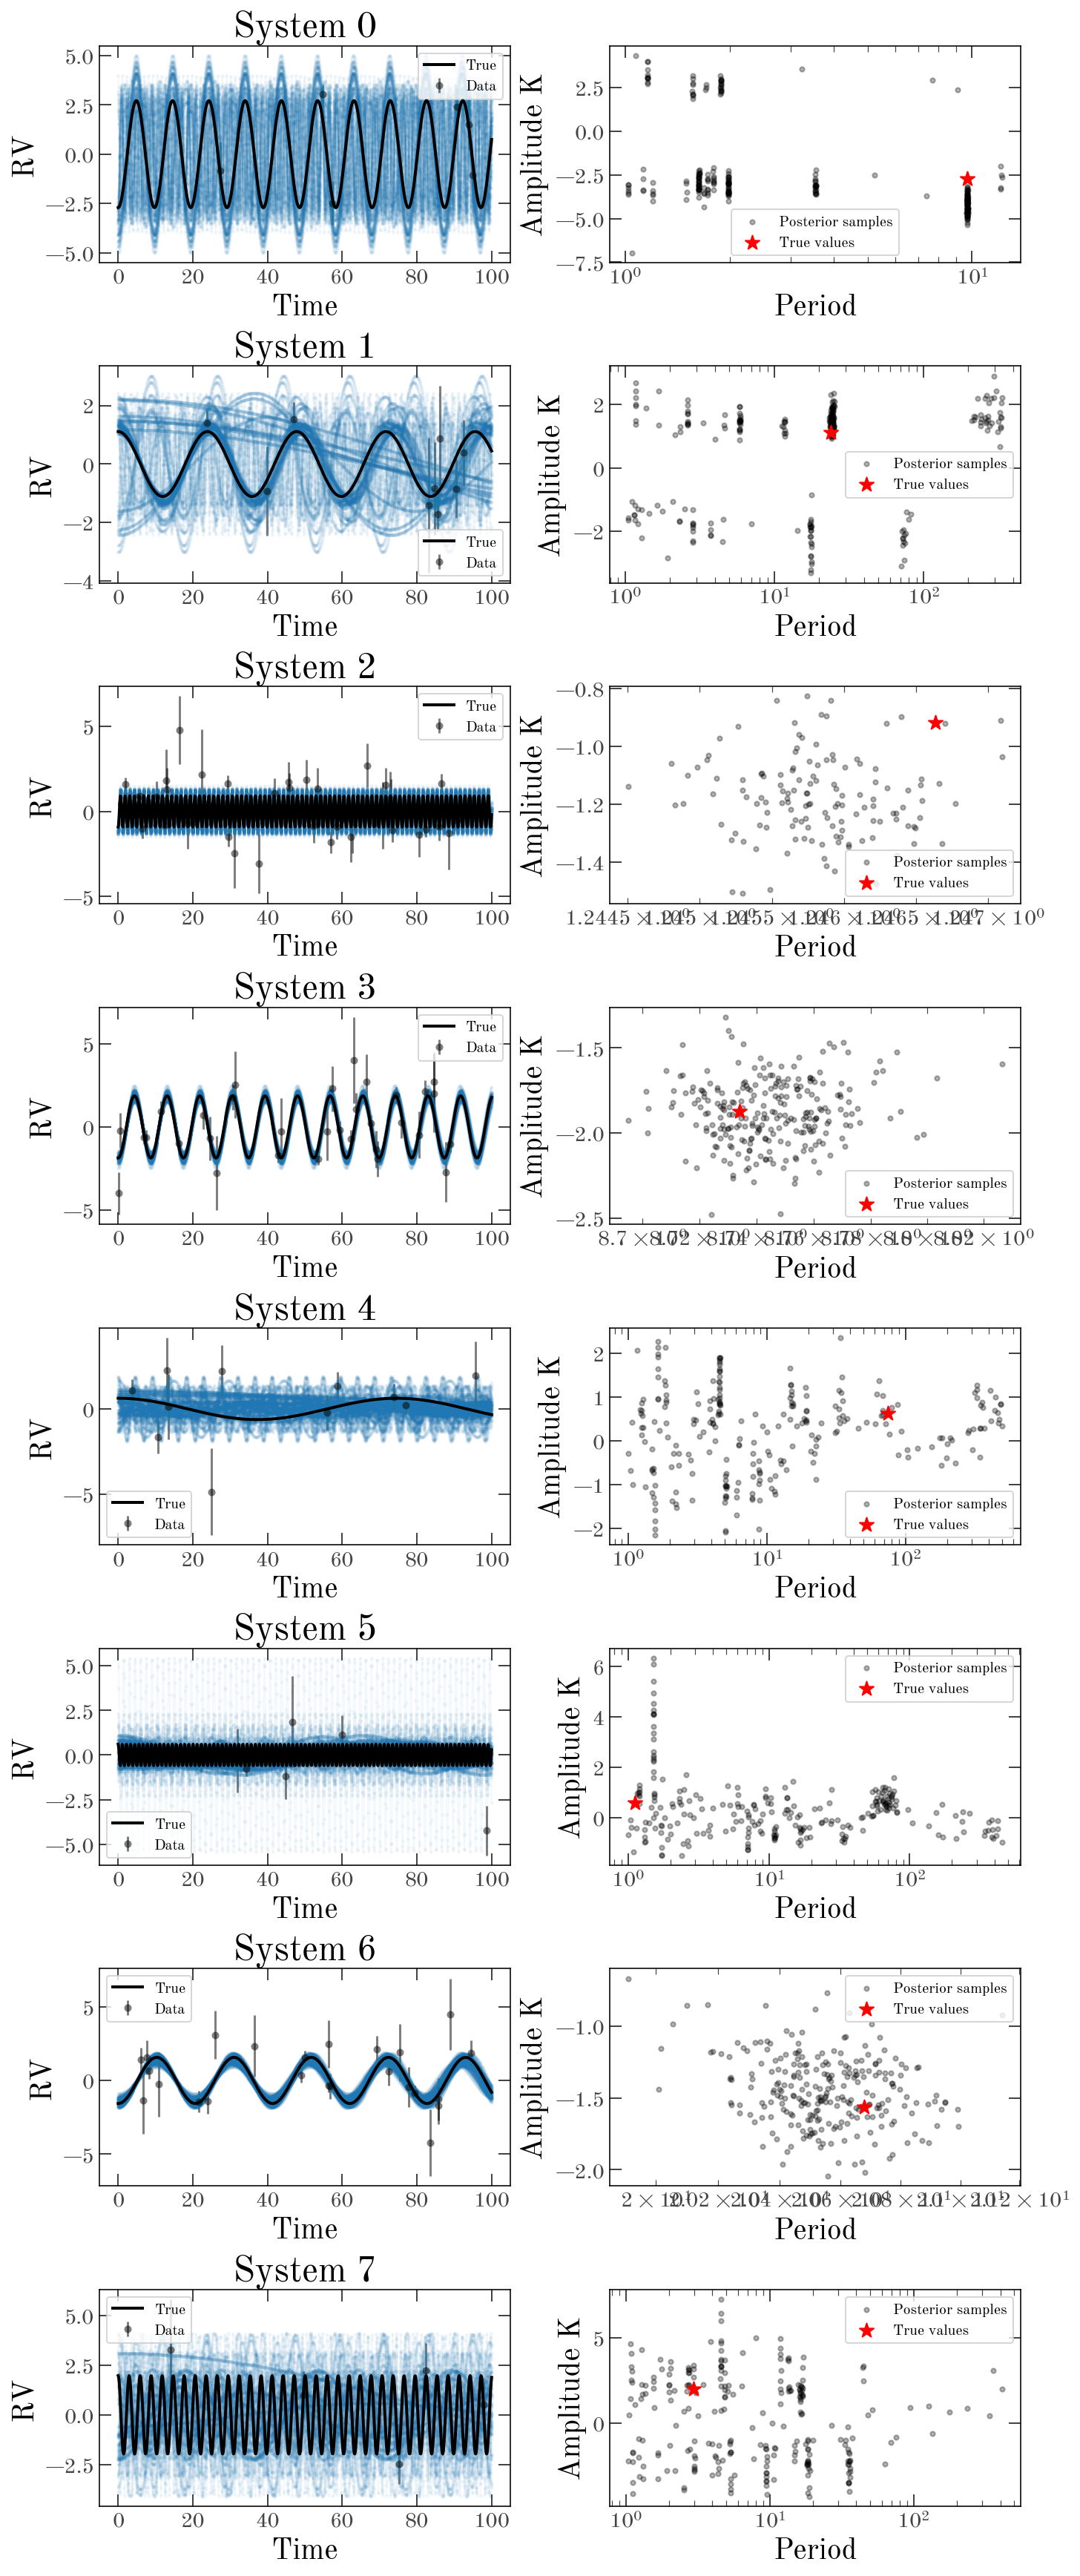

In [23]:
n_plot = 8

# Visualize results
fig, axes = plt.subplots(n_plot, 2, figsize=(10, 3 * n_plot), layout="constrained")

for i in range(n_plot):
    ax_data, ax_params = axes[i]

    # Plot data
    ax_data.errorbar(
        rv_data["time"][i],
        rv_data["rv"][i],
        yerr=rv_data["rv_err"][i],
        fmt="o",
        alpha=0.5,
        label="Data",
    )

    # Plot model curves from posterior samples
    t_grid = np.linspace(0, time_baseline, 1024)
    for P, K in zip(results[i]["periods"][:50], results[i]["amplitudes"][:50]):
        rv_model = K * np.cos(2 * np.pi * t_grid / P)
        ax_data.plot(t_grid, rv_model, "C1", alpha=0.05, lw=1)

    # Plot true model
    rv_true = true_amps[i] * np.cos(2 * np.pi * t_grid / true_periods[i])
    ax_data.plot(t_grid, rv_true, "k-", lw=2, label="True", zorder=10)

    ax_data.set_xlabel("Time")
    ax_data.set_ylabel("RV")
    ax_data.legend()
    ax_data.set_title(f"System {i}")

    # Plot period vs amplitude posterior samples
    ax_params.scatter(
        results[i]["periods"],
        results[i]["amplitudes"],
        alpha=0.3,
        s=10,
        label="Posterior samples",
    )
    ax_params.scatter(
        true_periods[i],
        true_amps[i],
        color="red",
        s=100,
        marker="*",
        label="True values",
        zorder=10,
    )
    ax_params.set_xlabel("Period")
    ax_params.set_ylabel("Amplitude K")
    ax_params.set_xscale("log")
    ax_params.legend()

## Binary fraction estimation

Now we'll compute the binary fraction using the posterior samples. The procedure:
1. For each posterior sample, compute whether it falls in our selection cuts (period and amplitude)
2. Compute per-star probability $p_n$ of being a "binary"
3. Maximize the mixture model likelihood to get binary fraction estimate
(i.e. the path outlined in the Overleaf note I shared)

In [24]:
def binary_fraction_log_likelihood(f, p_values):
    """Log-likelihood for binary fraction given per-star probabilities."""
    # avoid log(0)
    mix = jnp.clip((1 - f) * (1 - p_values) + f * p_values, 1e-12, 1.0)
    return jnp.sum(jnp.log(mix))


@jax.jit
def neg_log_likelihood_jit(f, p_values):
    """JIT-compiled negative log-likelihood."""
    return -binary_fraction_log_likelihood(f, p_values)


def estimate_binary_fraction(results):
    """Maximum likelihood estimate of binary fraction using JAX optimizer."""
    p_values = jnp.array(
        [
            jnp.sum(
                (results[n]["periods"] < binary_max_period)
                & (jnp.abs(results[n]["amplitudes"]) > binary_min_amp)
            )
            / results[n]["periods"].shape[0]
            for n in range(len(results))
        ]
    )

    # Create a closure that captures p_values
    def objective(f):
        return neg_log_likelihood_jit(f, p_values)

    # Use JAX optimizer with JIT
    result = jax.scipy.optimize.minimize(
        objective,
        x0=jnp.array([0.5]),
        method="BFGS",
    )

    return result.x[0]

In [25]:
def bootstrap_binary_fraction_uncertainty(results, n_bootstrap=1000, seed=42):
    """Estimate uncertainty on binary fraction via bootstrap resampling."""
    n_stars = len(results)

    # Pre-compute p_values for all stars (do this once outside the loop)
    p_values = jnp.array(
        [
            jnp.sum(
                (results[n]["periods"] < binary_max_period)
                & (jnp.abs(results[n]["amplitudes"]) > binary_min_amp)
            )
            / results[n]["periods"].shape[0]
            for n in range(n_stars)
        ]
    )

    @jax.jit
    def estimate_f_from_p_values(p_vals):
        """JIT-compiled ML estimate given p_values."""

        def objective(f):
            return neg_log_likelihood_jit(f, p_vals)

        result = jax.scipy.optimize.minimize(
            objective,
            x0=jnp.array([0.5]),
            method="BFGS",
        )
        return result.x[0]

    @jax.jit
    def single_bootstrap(key):
        """Single bootstrap iteration."""
        # Resample p_values with replacement
        indices = jax.random.choice(key, n_stars, shape=(n_stars,), replace=True)
        p_resampled = p_values[indices]
        return estimate_f_from_p_values(p_resampled)

    # Generate all random keys at once
    key = jax.random.PRNGKey(seed)
    keys = jax.random.split(key, n_bootstrap)

    # Vectorize over all bootstrap samples
    f_bootstrap = jax.vmap(single_bootstrap)(keys)

    return f_bootstrap

In [26]:
# Maximum likelihood:
estimate_binary_fraction(results)

Array(0.32093872, dtype=float64)

In [27]:
f_bootstrap = bootstrap_binary_fraction_uncertainty(results, n_bootstrap=1000, seed=42)

f_median = jnp.median(f_bootstrap)
f_16, f_84 = jnp.percentile(f_bootstrap, jnp.array([16, 84]))

print(
    f"Median bootstrap binary fraction: {f_median:.3f} (+{f_84 - f_median:.3f}/-{f_median - f_16:.3f})"
)
print(f"True binary fraction: {true_binary_frac:.3f}")

Median bootstrap binary fraction: 0.321 (+0.018/-0.020)
True binary fraction: 0.341
